# This notebook performs fault slip analysis (FSA) based on principal stresses from CMG geomechanical simulations. The following data are needed:
- Grid cell coordinates and fault ID extracted from Petrel exported files.
- Principal stresses (STRESMXP, STRESMNP, STRESINT) extracted from CMG simulation results (sr3/gmch.sr3 -> rwo -> numpy).

# Step 1: Peform fault slip analysis

## Calculate and save the following (all are numpy arrays):  
1. Fault slip indicator (FSI: 0 no slip, 1 slip) in a folder: shape (n_is,n_js,n_ks,n_times) for each case
2. The ratio of shear stress to effective normal stress in a folder: shape (n_is,n_js,n_ks,n_times) for each case
3. Mean stress ratio in a file: shape (n_cases,n_faults,n_times)
4. Mean shear stress in a file: shape (n_cases,n_faults,n_times)
5. Total number of failed cells in a file: shape (n_cases,n_faults,n_times)

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import sys

# add src to path
repo_root = Path.cwd().parent
sys.path.append(str(repo_root / "src"))

from fault_slip_analysis import FSA_stress_based

################## User Inputs ############################## 
name_prefix = 'test_260703' # file name prefix
n_cases = 10 # number of simulation cases
n_faults = 2 # number of faults
n_times = 3 # number of simulation time steps, add the initial time step
fault_cohesion = 1 # fault cohesion in kPa
n_is,n_js,n_ks = 139, 248, 23 # number of grid cells in the i,j,k directions
# paths to input data
fault_strike_dip_csv_path = repo_root/'data'/'Vienna_geothermal'/'raw'/'JD_geothermal_fault_strike_dip.csv' # path to the fault strike and dip CSV file
coor_fault_npy_path = repo_root/'data'/'Vienna_geothermal'/'coor_fault'/'JD_geothermal_coor&fault.npy' # path to the grid coordinates and fault ID numpy file
parameters_csv_path = repo_root/'data'/'Vienna_geothermal'/'params_responses'/f'{name_prefix}_CMG_parameters.csv' # path to the parameters CSV file
principal_stresses_folder = repo_root/'results'/'Vienna_geothermal'/'principal_stresses'/f'{name_prefix}' # path to the folder containing the principal stress numpy files
# paths to output folder
fault_slip_analysis_folder = repo_root/'results'/'Vienna_geothermal'/'fault_slip_analysis'
################## End of User Inputs #######################

# load data
fault_info = pd.read_csv(fault_strike_dip_csv_path)
coor_fault = np.load(coor_fault_npy_path)
parameters = pd.read_csv(parameters_csv_path)

# create save folders
stress_ratio_folder = fault_slip_analysis_folder/f'{name_prefix}_stress_ratio' # path to the folder to save stress ratio numpy files
stress_ratio_folder.mkdir(parents=True, exist_ok=True)
FSI_folder = fault_slip_analysis_folder/f'{name_prefix}_FSI' # path to the folder to save fault slip indicator numpy files
FSI_folder.mkdir(parents=True, exist_ok=True)

# initialize an array to hold mean shear stress for all cases, faults and time steps
mean_tau = np.full((n_cases,n_faults,n_times), np.nan) # array shape (n_cases,n_faults,n_times)
# initialize an array to hold stress ratio for each case
stress_ratio_by_fault = np.full((n_is,n_js,n_ks,n_times), np.nan) # array shape (n_is,n_js,n_ks,n_times)
# initialize an array to hold mean stress ratio for all cases, faults and time steps
mean_stress_ratio = np.full((n_cases,n_faults,n_times), np.nan) # array shape (n_cases,n_faults,n_times)
# initialize an array to hold fault slip indicator for each case
FSI_by_fault = np.full((n_is,n_js,n_ks,n_times), np.nan) # array shape (n_is,n_js,n_ks,n_times)
# initialize an array to hold total number of failed cells for all cases, faults and time steps
total_failed_cells = np.full((n_cases,n_faults,n_times), np.nan) # array shape (n_cases,n_faults,n_times)

# run analysis
# for case_num in tqdm(range(15,16), desc='Running stress-based fault slip analysis'):
for case_num in tqdm(range(1,n_cases+1), desc='Running stress-based fault slip analysis'):
    # load principal stress arrays
    SH = np.load(principal_stresses_folder/f'case{case_num}_STRESMXP.npy')
    Sh = np.load(principal_stresses_folder/f'case{case_num}_STRESMNP.npy')
    Sv = np.load(principal_stresses_folder/f'case{case_num}_STRESINT.npy')
    # extract the azimuth of the maximum horizontal stress from the parameter dataframe
    SH_azi = parameters.loc[parameters["case_name"] == f'case{case_num}','SH_azi_deg'].iloc[0]

    for fault_id in range(n_faults):
        # run fault slip analysis
        row = fault_info.loc[fault_info['fault_id'] == fault_id].iloc[0]
        sigma, tau, fault_slip_indicator = FSA_stress_based(
            SH = SH,
            Sh = Sh,
            Sv = Sv,
            SH_azi = SH_azi,
            fault_strike = row['fault_strike_deg'],
            fault_dip = row['dip_angle_deg'],
            fault_cohesion = fault_cohesion,
            friction_coefficient = 0.6
            )
        
        # mask a fault based on its id
        fault_id_mask = (coor_fault[:,:,:,3] == fault_id)

        # calculate the mean shear stress for all cases, faults and time steps (note to covert kPa to MPa)
        mean_tau[case_num-1,fault_id,:] = np.nanmean(tau[fault_id_mask]/1000,axis=0) # array shape (n_cases,n_faults,n_times)

        # calculate stress ratio for each fault
        ratio = (tau - fault_cohesion) / sigma
        stress_ratio_by_fault[fault_id_mask] = ratio[fault_id_mask]
        # calculate the mean stress ratio for all cases, faults and time steps
        mean_stress_ratio[case_num-1,fault_id,:] = np.nanmean(stress_ratio_by_fault[fault_id_mask],axis=0) # array shape (n_cases,n_faults,n_times)

        # extract fault slip indicator for each fault 
        FSI_by_fault[fault_id_mask] = fault_slip_indicator[fault_id_mask] # array shape (n_is,n_js,n_ks,n_times)
        
        # calculate the total number of failed cells for all cases, faults and time steps
        total_failed_cells[case_num-1,fault_id,:] = np.nansum(FSI_by_fault[fault_id_mask],axis=0) # array shape (n_cases,n_faults,n_times)

    # save stress ratio for each case
    np.save(stress_ratio_folder/f'case{case_num}_stress_ratio.npy', stress_ratio_by_fault)
    # save fault slip indicator for each case
    np.save(FSI_folder/f'case{case_num}_FSI.npy', FSI_by_fault)

# save the mean shear stress
np.save(fault_slip_analysis_folder/f'{name_prefix}_mean_shear_stress.npy',mean_tau)
# save the mean stress ratio
np.save(fault_slip_analysis_folder/f'{name_prefix}_mean_stress_ratio.npy',mean_stress_ratio)
# save the total number of failed cells
np.save(fault_slip_analysis_folder/f'{name_prefix}_total_failed_cells.npy',total_failed_cells)

print("\nFinished analyzing all cases.")

Running stress-based fault slip analysis:   0%|          | 0/10 [00:00<?, ?it/s]

Running stress-based fault slip analysis: 100%|██████████| 10/10 [01:49<00:00, 10.91s/it]


Finished analyzing all cases.


## Check results

In [9]:
################## User Inputs ############################## 
name_prefix = 'test_260703' # file name prefix

# paths to output folder
fault_slip_analysis_folder = repo_root/'results'/'Vienna_geothermal'/'fault_slip_analysis'
################## End of User Inputs #######################
# 
# name_prefix = '250922'
# arr = np.load('data/250919_FSA/case10_FSA.npy')
# arr = np.load('data/250922_mean_stress_ratio.npy')
# arr = np.load('data/250922_mean_tau.npy')
arr = np.load(fault_slip_analysis_folder/f'{name_prefix}_total_failed_cells.npy')
print('(n_cases,n_faults,n_times) = ', arr.shape)
print(np.nonzero(arr[:,0,2]))


(n_cases,n_faults,n_times) =  (10, 2, 3)
(array([], dtype=int64),)


In [13]:
# arr2 = np.load(fault_slip_analysis_folder/'test_260703_stress_ratio'/'case1_stress_ratio.npy')
# arr2 = np.load(fault_slip_analysis_folder/'test_260703_mean_stress_ratio.npy')
arr2 = np.load(fault_slip_analysis_folder/'test_260703_mean_tau.npy')
arr2.shape

(10, 2, 3)

In [145]:
name_prefix = '251017'
arr = np.load(f'data/{name_prefix}_total_failed_cells.npy')
print(arr.shape)
print(np.nonzero(arr[:,0,2]))
# arr[:,0,:]
parameters = pd.read_csv(base_path/'data'/'params_responses'/f'{name_prefix}_CMG_parameters.csv')
print(parameters['SH_MPa/km'].iloc[np.nonzero(arr[:,0,2])]*(-1))
print(parameters['SH_azi_deg'].iloc[np.nonzero(arr[:,0,2])])

(90, 12, 6)
(array([25, 53]),)
25    18.9643
53    18.7658
Name: SH_MPa/km, dtype: float64
25    319.7118
53    319.6593
Name: SH_azi_deg, dtype: float64


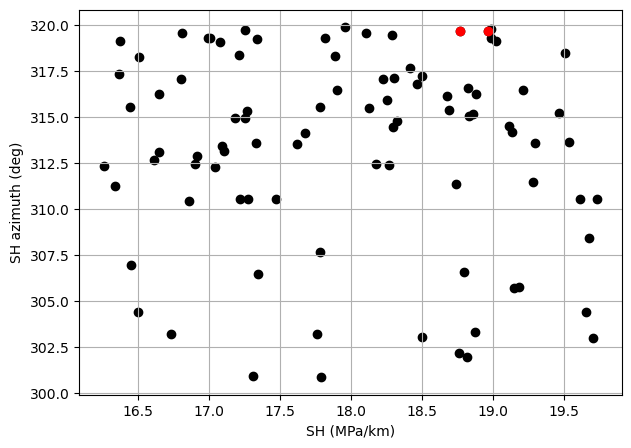

In [140]:
import matplotlib.pyplot as plt

parameters = pd.read_csv(base_path/'data'/'params_responses'/f'{name_prefix}_CMG_parameters.csv')
# plt.figure(1) creates a new, separate window.
plt.figure(1, figsize=(7, 5))
plt.scatter(parameters['SH_MPa/km']*(-1), parameters['SH_azi_deg'],color='black')
plt.scatter(parameters['SH_MPa/km'].iloc[np.nonzero(arr[:,0,2])]*(-1), parameters['SH_azi_deg'].iloc[np.nonzero(arr[:,0,2])],color='red')
# plt.scatter(high_ratio['Vert_Base_Are'], high_ratio['SH_azi_deg'],color='red',label='high stress ratio')
plt.xlabel('SH (MPa/km)')
plt.ylabel('SH azimuth (deg)')
plt.grid(True)
# plt.legend(loc='lower right')

## Calculate total number of slipped cells for (n_cases,n_faults,n_times)

In [16]:
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

repo_root = Path.cwd().parent

################## User Inputs ############################## 
name_prefix = 'test_260703' # file name prefix
n_cases = 10 # number of simulation cases
n_faults = 2 # number of faults
n_times = 3 # number of simulation time steps, add the initial time step
# paths to input data
fault_strike_dip_csv_path = repo_root/'data'/'Vienna_geothermal'/'raw'/'JD_geothermal_fault_strike_dip.csv' # path to the fault strike and dip CSV file
coor_fault_npy_path = repo_root/'data'/'Vienna_geothermal'/'coor_fault'/'JD_geothermal_coor&fault.npy' # path to the grid coordinates and fault ID numpy file
# paths to output folder
fault_slip_analysis_folder = repo_root/'results'/'Vienna_geothermal'/'fault_slip_analysis' # path to the folder containing the fault slip analysis results
################## End of User Inputs #######################

# load data
fault_info = pd.read_csv(fault_strike_dip_csv_path)
coor_fault = np.load(coor_fault_npy_path)

FSI_combined = np.full((n_cases,n_faults,n_times), np.nan)

for case_num in tqdm(range(1,n_cases+1), desc='Combining FSI results for all cases'):
    FSI = np.load(fault_slip_analysis_folder/f'{name_prefix}_FSI/case{case_num}_FSI.npy')

    for fault_id in range(0,n_faults):
        # save analysis to the specific fault 
        fault_id_mask = (coor_fault[:,:,:,3] == fault_id)
        FSI_combined[case_num-1,fault_id,:] = np.nansum(FSI[fault_id_mask],axis=0)

# save
np.save(fault_slip_analysis_folder/f'{name_prefix}_FSI_combined.npy',FSI_combined)

print("\nFinished combining FSI results for all cases to one numpy array.")
# np.savetxt(base_path/'data'/f'{save_file_prefix}_FSA_combined.csv',FSI_combined,delimiter=",",fmt="%.4f")

Combining FSI results for all cases:   0%|          | 0/10 [00:00<?, ?it/s]

Combining FSI results for all cases: 100%|██████████| 10/10 [00:00<00:00, 109.35it/s]


Finished combining FSI results for all cases to one numpy array.


In [15]:
print(FSI_combined.shape)
print(FSI_combined[4,:,:])

(10, 2, 3)
[[0. 0. 0.]
 [0. 0. 0.]]


## calculate the (number of cases with fault slip / total cases)

In [50]:
import numpy as np
from pathlib import Path

name_prefix = '250922'
base_path = Path('.')

FSA_combined = np.load(base_path/'data'/f'{name_prefix}_FSA_combined.npy')
no_slip_count = np.sum(FSA_combined == 0, axis=0)
slip_probability = 1 - no_slip_count/FSA_combined.shape[0]
# np.savetxt(base_path/'data'/f'{save_file_prefix}_FSA_probability.csv',slip_probability,delimiter=",",fmt="%.4f")
# Save as CSV
df = pd.DataFrame(
    slip_probability,
    columns=[f"time_{t}" for t in range(n_times)]
)
df.insert(0, "fault_id", range(n_faults))

df.to_csv(base_path/'data'/f'{name_prefix}_FSA_probability.csv', index=False, float_format="%.4f")
df

,fault_id,time_0,time_1,time_2,time_3,time_4,time_5
0,0,0.0,0.0,0.022222,0.033333,0.033333,0.022222
1,1,0.0,0.0,0.000000,0.000000,0.000000,0.000000
2,2,0.0,0.0,0.000000,0.000000,0.000000,0.000000
3,3,0.0,0.0,0.000000,0.000000,0.000000,0.000000
4,4,0.0,0.0,0.033333,0.011111,0.011111,0.011111
5,5,0.0,0.0,0.000000,0.000000,0.000000,0.000000
6,6,0.0,0.0,0.033333,0.066667,0.044444,0.044444
7,7,0.0,0.0,0.000000,0.000000,0.000000,0.000000
8,8,0.0,0.0,0.000000,0.000000,0.000000,0.000000
9,9,0.0,0.0,0.000000,0.000000,0.000000,0.000000
